# Scenario II & III — Ensemble Objective Search
## Melanoma Classification via Bayesian Optimisation with Tree-structured Parzen Estimator (TPE)

Notebook ini menggabungkan hasil dari keempat model Scenario I (DenseNet-121, InceptionV3, Xception, ViT-Pretrained) ke dalam pipeline ensemble dua bagian:

**Bagian A — Unified TPE Search (500 trial)**
Mencari **bobot model ensemble** dan **bobot fungsi objektif** secara simultan dalam satu study. Tidak ada formulasi objektif yang dikunci manual — TPE menentukan kombinasi AUC, Recall, F1, dan Accuracy yang menghasilkan ensemble terbaik pada validation split.

**Bagian B — Seleksi & Evaluasi**
Trial terbaik dipilih berdasarkan *selection score* gabungan DS1 + DS2 (AUC-heavy: 0.50 DS1-AUC + 0.30 DS2-AUC + 0.10 DS1-Recall + 0.10 DS2-Recall), lalu diterapkan ke:
- **Scenario II**: evaluasi ensemble pada DS1 (Kaggle test set)
- **Scenario III**: evaluasi cross-dataset pada DS2 (Mendeley) tanpa fine-tuning

## 1. Import & Konfigurasi Plot

Mengimpor seluruh library yang dibutuhkan dan mengatur style matplotlib global (font serif, tanpa spines atas/kanan, grid transparan) yang konsisten di seluruh visualisasi notebook ini.

In [2]:
import json, random
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams.update({
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
})
print('Imports ready.')


Imports ready.


## 2. Konfigurasi

Mendefinisikan seluruh konstanta dalam satu tempat:

- **`RESULTS`**: path ke direktori output masing-masing model Scenario I. Key internal (`vit_scratch`) sengaja dibiarkan karena terikat ke nama file `.npy` yang sudah ada di disk; label display tetap `ViT-Pretrained` di `MODEL_LABELS`.
- **`N_TRIALS = 500`**: total trial untuk unified TPE study — single source of truth.
- **`SELECTION_W`**: bobot seleksi trial terbaik. AUC mendominasi karena threshold-independent dan robust untuk data tidak seimbang. Recall disertakan karena *false negative = missed cancer*.
- **`PAPER_REF`** dan **`SOTA_REF`**: baseline dari paper acuan dan state-of-the-art untuk perbandingan hasil akhir.

In [3]:
BASE_DIR = Path(r'D:\Tree-Structured Parzen Estimator\main')

RESULTS = {
    'densenet121'   : BASE_DIR / '[1] densenet121'  / 'full_pipeline_results',
    'inception_v3'  : BASE_DIR / '[2] inceptionv3'  / 'full_pipeline_results',
    'vit_scratch': BASE_DIR / '[3] vit'          / 'full_pipeline_results',
    'xception'      : BASE_DIR / '[4] xception'     / 'full_pipeline_results',
}

OUTPUT_DIR = BASE_DIR / '[5] ensemble_learning' / 'ensemble_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_KEYS   = ['densenet121', 'inception_v3', 'xception', 'vit_scratch']
MODEL_LABELS = {
    'densenet121'   : 'DenseNet-121',
    'inception_v3'  : 'InceptionV3',
    'xception'      : 'Xception',
    'vit_scratch' : 'ViT-Pretrained',
}
CLASS_NAMES = ['Benign', 'Malignant']

N_TRIALS  = 500
BASE_SEED = 42

SELECTION_W = {
    'ds1_auc'    : 0.50,
    'ds2_auc'    : 0.30,
    'ds1_recall' : 0.10,
    'ds2_recall' : 0.10,
}

PAPER_REF = {
    'DenseNet-121'  : {'accuracy': 0.9450, 'precision': 0.9390, 'recall': 0.9504, 'f1': 0.9447},
    'InceptionV3'   : {'accuracy': 0.9120, 'precision': 0.9320, 'recall': 0.8962, 'f1': 0.9137},
    'Xception'      : {'accuracy': 0.9380, 'precision': 0.9300, 'recall': 0.9451, 'f1': 0.9375},
    'ViT-Pretrained': {'accuracy': 0.8825, 'precision': 0.9050, 'recall': 0.8660, 'f1': 0.8850},
    'Ensemble'      : {'accuracy': 0.9525, 'precision': 0.9420, 'recall': 0.9622, 'f1': 0.9520},
}
SOTA_REF = {
    'Mahmud_DS1': {
        'label': 'Mahmud et al.', 'dataset': 'DS1', 'method': 'Proposed Xception',
        'accuracy': 0.9109, 'precision': 0.9472, 'recall': 0.9179, 'f1': 0.9195, 'auc': 0.9615,
    },
    'Mahmud_DS2': {
        'label': 'Mahmud et al.', 'dataset': 'DS2', 'method': 'Proposed Xception',
        'accuracy': 0.8929, 'precision': 0.8961, 'recall': 0.8917, 'f1': 0.8939, 'auc': 0.9371,
    },
    'Sabir_DS2': {
        'label': 'Sabir & Mehmood', 'dataset': 'DS2', 'method': 'EfficientNet-B0',
        'accuracy': 0.9700, 'precision': 0.9500, 'recall': 0.9900, 'f1': 0.9700, 'auc': 0.9900,
    },
}

print(f'Unified TPE study : {N_TRIALS} total trials')
print(f'Selection score   : {SELECTION_W}')
print()
all_ok = True
for arch, path in RESULTS.items():
    status = 'OK' if path.exists() else 'NOT FOUND'
    if not path.exists(): all_ok = False
    print(f'  {MODEL_LABELS[arch]:<16} [{status}]')
print('Config OK.' if all_ok else 'WARNING: one or more result dirs missing.')

Unified TPE study : 500 total trials
Selection score   : {'ds1_auc': 0.5, 'ds2_auc': 0.3, 'ds1_recall': 0.1, 'ds2_recall': 0.1}

  DenseNet-121     [OK]
  InceptionV3      [OK]
  ViT-Pretrained   [OK]
  Xception         [OK]
Config OK.


## 3. Load Probabilitas Model

Memuat array probabilitas (`.npy`) yang dihasilkan oleh masing-masing model Scenario I untuk tiga split:

- **`all_probs_ds1`**: probabilitas pada DS1 test set (Kaggle) — digunakan di Scenario II.
- **`all_val_probs`**: probabilitas pada validation split — digunakan selama TPE search.
- **`all_probs_ds2`**: probabilitas pada DS2 (Mendeley) — digunakan di Scenario III.

Jika ada file DS2 yang tidak ditemukan, error eksplisit diangkat sebelum cell berikutnya dijalankan untuk mencegah *silent wrong output* berupa kolom bernilai `0.0000` tanpa peringatan.

In [4]:
all_probs_ds1, all_val_probs, all_probs_ds2 = {}, {}, {}
_missing_ds2 = []

for arch in MODEL_KEYS:
    d = RESULTS[arch]
    try:
        def _load(fname):
            p = np.load(d / fname)
            return p[:, 1] if p.ndim == 2 else p

        all_probs_ds1[arch] = _load(f'probs_ds1_{arch}.npy')
        all_val_probs[arch] = _load(f'val_probs_{arch}.npy')
        all_probs_ds2[arch] = _load(f'probs_ds2_{arch}.npy')
        print(f'  {MODEL_LABELS[arch]:<16} DS1={all_probs_ds1[arch].shape}  '
              f'val={all_val_probs[arch].shape}  DS2={all_probs_ds2[arch].shape}')
    except FileNotFoundError as e:
        print(f'  {MODEL_LABELS[arch]:<16} MISSING: {e}')
        _missing_ds2.append(arch)

ref        = RESULTS['densenet121']
ds1_labels = np.load(ref / 'ds1_labels.npy')
ds2_labels = np.load(ref / 'ds2_labels.npy')
val_labels = np.load(ref / 'val_labels.npy')
print(f'\nLabels — DS1: {ds1_labels.shape}  DS2: {ds2_labels.shape}  val: {val_labels.shape}')

tpe_best_params = {}
for arch in MODEL_KEYS:
    p = RESULTS[arch] / f'tpe_{arch}.json'
    if p.exists():
        with open(p) as f:
            tpe_best_params[arch] = json.load(f)

print(f'{len(all_probs_ds1)}/{len(MODEL_KEYS)} models loaded (DS1).')
print(f'{len(all_probs_ds2)}/{len(MODEL_KEYS)} models loaded (DS2).')

if not all_probs_ds2:
    raise RuntimeError(
        'FATAL: all_probs_ds2 kosong — semua file DS2 tidak ditemukan.\n'
        'Scenario III dan DS2 columns di summary table akan salah semua.\n'
        'Pastikan file probs_ds2_<arch>.npy tersedia sebelum melanjutkan.'
    )
elif _missing_ds2:
    print(f'\nWARNING: {len(_missing_ds2)} model tidak memiliki data DS2: {_missing_ds2}')
    print('Scenario III akan dijalankan hanya untuk model yang tersedia.')

  DenseNet-121     DS1=(2000,)  val=(1782,)  DS2=(1000,)
  InceptionV3      DS1=(2000,)  val=(1782,)  DS2=(1000,)
  Xception         DS1=(2000,)  val=(1782,)  DS2=(1000,)
  ViT-Pretrained   DS1=(2000,)  val=(1782,)  DS2=(1000,)

Labels — DS1: (2000,)  DS2: (1000,)  val: (1782,)
4/4 models loaded (DS1).
4/4 models loaded (DS2).


## 4. Helper Functions

Mendefinisikan tiga fungsi utilitas yang digunakan di seluruh notebook:

- **`compute_metrics(labels, probs)`**: menghitung accuracy, precision, recall, F1, AUC, dan confusion matrix dari array probabilitas dan label ground truth.
- **`weighted_ensemble(probs_dict, weights, keys)`**: menggabungkan probabilitas beberapa model dengan bobot yang sudah dinormalisasi (weighted average).
- **`make_objective(obj_weights)`**: membuat fungsi objektif Optuna sederhana dengan bobot metrik yang dikunci — digunakan untuk referensi dan perbandingan dengan unified objective.

In [5]:
def compute_metrics(labels, probs, threshold=0.5):
    """Hitung metrik klasifikasi biner (probs harus 1-D)."""
    preds = (probs >= threshold).astype(int)
    try:
        auc = roc_auc_score(labels, probs)
    except Exception:
        auc = 0.0
    return {
        'accuracy' : float(accuracy_score(labels, preds)),
        'precision': float(precision_score(labels, preds, zero_division=0)),
        'recall'   : float(recall_score(labels, preds, zero_division=0)),
        'f1'       : float(f1_score(labels, preds, zero_division=0)),
        'auc'      : float(auc),
        'conf_mat' : confusion_matrix(labels, preds).tolist(),
        'threshold': float(threshold),
    }


def weighted_ensemble(probs_dict, weights, keys):
    """Weighted-average probabilitas dari beberapa model (1-D arrays)."""
    out = np.zeros_like(probs_dict[keys[0]], dtype=np.float64)
    for k, w in zip(keys, weights):
        out += w * probs_dict[k]
    return out


def make_objective(obj_weights):
    """Buat Optuna objective — maksimalkan kombinasi metrik pada validation split."""
    def _fn(trial):
        raw    = [trial.suggest_float(f'w_{k}', 0.05, 1.0) for k in MODEL_KEYS]
        w_norm = [r / sum(raw) for r in raw]
        probs  = weighted_ensemble(all_val_probs, w_norm, MODEL_KEYS)
        preds  = (probs >= 0.5).astype(int)
        vals   = {
            'acc'      : accuracy_score(val_labels, preds),
            'recall'   : recall_score(val_labels, preds, zero_division=0),
            'precision': precision_score(val_labels, preds, zero_division=0),
            'f1'       : f1_score(val_labels, preds, zero_division=0),
        }
        try:
            vals['auc'] = roc_auc_score(val_labels, probs)
        except Exception:
            vals['auc'] = vals['acc']
        return sum(obj_weights.get(m, 0.0) * vals[m] for m in obj_weights)
    return _fn


print('Helpers ready: compute_metrics, weighted_ensemble, make_objective')


Helpers ready: compute_metrics, weighted_ensemble, make_objective


## 5. Konfigurasi Bayesian Objective Search

Mendefinisikan konfigurasi study Optuna sebelum dijalankan:

- **Ruang pencarian**: 4 bobot model (`[0.05, 1.0]`) dan 4 bobot objektif (`[0.0, 1.0]`) — keduanya kontinu dan dinormalisasi di dalam fungsi objektif sehingga selalu berjumlah 1.
- **`N_STARTUP`**: 20% dari total trial digunakan sebagai eksplorasi random sebelum surrogate model TPE aktif. Validasi `N_STARTUP < N_TRIALS` dijalankan di sini untuk mencegah kondisi TPE tidak pernah aktif jika `N_TRIALS` diubah ke nilai kecil.
- **`multivariate=True`**: TPE menangkap korelasi antar parameter — penting karena bobot model dan bobot objektif saling mempengaruhi nilai yang dioptimasi.

In [6]:

STUDY_SEED = BASE_SEED

N_STARTUP = max(20, N_TRIALS // 5)
if N_STARTUP >= N_TRIALS:
    raise ValueError(
        f'N_STARTUP ({N_STARTUP}) >= N_TRIALS ({N_TRIALS}): '
        f'TPE tidak akan pernah aktif. Naikkan N_TRIALS atau kurangi N_STARTUP.'
    )

print('Bayesian Objective Search — Unified Study')
print(f'  Search space    : 4 bobot model + 4 bobot objektif (semua kontinu)')
print(f'  Total trials    : {N_TRIALS}')
print(f'  Startup trials  : {N_STARTUP}  (random exploration sebelum TPE aktif)')
print(f'  TPE trials      : {N_TRIALS - N_STARTUP}  ({(N_TRIALS-N_STARTUP)/N_TRIALS*100:.0f}% dari total)')
print(f'  Seed            : {STUDY_SEED}')
print()
print('  Parameter          Range        Keterangan')
print('  ' + '-' * 55)
print('  w_densenet121      [0.05, 1.0]  → bobot model (dinormalisasi)')
print('  w_inception_v3     [0.05, 1.0]  → bobot model (dinormalisasi)')
print('  w_xception         [0.05, 1.0]  → bobot model (dinormalisasi)')
print('  w_vit_scratch   [0.05, 1.0]  → bobot model (dinormalisasi)')
print('  obj_auc            [0.0,  1.0]  → bobot AUC dalam fungsi objektif')
print('  obj_recall         [0.0,  1.0]  → bobot Recall dalam fungsi objektif')
print('  obj_f1             [0.0,  1.0]  → bobot F1 dalam fungsi objektif')
print('  obj_acc            [0.0,  1.0]  → bobot Accuracy dalam fungsi objektif')
print()
print('  Catatan: bobot model dan bobot objektif masing-masing dinormalisasi')
print('  (sum=1) di dalam objective function — bukan di search space.')

Bayesian Objective Search — Unified Study
  Search space    : 4 bobot model + 4 bobot objektif (semua kontinu)
  Total trials    : 500
  Startup trials  : 100  (random exploration sebelum TPE aktif)
  TPE trials      : 400  (80% dari total)
  Seed            : 42

  Parameter          Range        Keterangan
  -------------------------------------------------------
  w_densenet121      [0.05, 1.0]  → bobot model (dinormalisasi)
  w_inception_v3     [0.05, 1.0]  → bobot model (dinormalisasi)
  w_xception         [0.05, 1.0]  → bobot model (dinormalisasi)
  w_vit_scratch   [0.05, 1.0]  → bobot model (dinormalisasi)
  obj_auc            [0.0,  1.0]  → bobot AUC dalam fungsi objektif
  obj_recall         [0.0,  1.0]  → bobot Recall dalam fungsi objektif
  obj_f1             [0.0,  1.0]  → bobot F1 dalam fungsi objektif
  obj_acc            [0.0,  1.0]  → bobot Accuracy dalam fungsi objektif

  Catatan: bobot model dan bobot objektif masing-masing dinormalisasi
  (sum=1) di dalam objective 

## 6. Bagian A — TPE Search & Rekap Trial

Menjalankan unified TPE study dan merekap seluruh trial yang selesai:

**`unified_objective(trial)`** — fungsi objektif yang dicari Optuna:
1. Menyarankan 4 bobot model dan 4 bobot metrik, masing-masing dinormalisasi (sum=1).
2. Menghitung probabilitas ensemble pada **validation split** (DS1 dan DS2 bersifat held-out).
3. Mengembalikan kombinasi linear: `w_auc×AUC + w_recall×Recall + w_f1×F1 + w_acc×Acc`.

Setelah study selesai, setiap trial yang valid dievaluasi ulang pada DS1 dan DS2 untuk menghasilkan metrik lengkap yang digunakan di Bagian B.

In [7]:
def unified_objective(trial):
    """
    Bayesian objective function — mencari SEKALIGUS:
      1. Bobot model ensemble  (w_densenet121, w_inception_v3, w_xception, w_vit_scratch)
      2. Bobot fungsi objektif (obj_auc, obj_recall, obj_f1, obj_acc)
    Keduanya dinormalisasi di dalam fungsi agar sum=1.
    Evaluasi dilakukan pada validation split; DS1 & DS2 bersifat held-out.
    """
    raw_model = [trial.suggest_float(f'w_{k}', 0.05, 1.0) for k in MODEL_KEYS]
    s_model   = sum(raw_model)
    w_model   = [r / s_model for r in raw_model]

    raw_obj = [
        trial.suggest_float('obj_auc',    0.0, 1.0),
        trial.suggest_float('obj_recall', 0.0, 1.0),
        trial.suggest_float('obj_f1',     0.0, 1.0),
        trial.suggest_float('obj_acc',    0.0, 1.0),
    ]
    s_obj = sum(raw_obj) + 1e-8
    w_auc, w_recall, w_f1, w_acc = [r / s_obj for r in raw_obj]

    probs = weighted_ensemble(all_val_probs, w_model, MODEL_KEYS)
    preds = (probs >= 0.5).astype(int)

    auc    = roc_auc_score(val_labels, probs)
    recall = recall_score(val_labels, preds, zero_division=0)
    f1     = f1_score(val_labels, preds, zero_division=0)
    acc    = accuracy_score(val_labels, preds)

    return w_auc * auc + w_recall * recall + w_f1 * f1 + w_acc * acc

random.seed(STUDY_SEED)
np.random.seed(STUDY_SEED)

study = optuna.create_study(
    direction  = 'maximize',
    sampler    = optuna.samplers.TPESampler(
        seed                      = STUDY_SEED,
        n_startup_trials          = N_STARTUP,
        multivariate              = True,
        warn_independent_sampling = False,
    ),
    study_name = 'unified_objective_search',
)
study.optimize(unified_objective, n_trials=N_TRIALS, show_progress_bar=True)

all_trials = []
for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE:
        continue

    p       = t.params
    raw_m   = [p[f'w_{k}'] for k in MODEL_KEYS]
    w_model = [r / sum(raw_m) for r in raw_m]

    raw_o   = [p['obj_auc'], p['obj_recall'], p['obj_f1'], p['obj_acc']]
    s_o     = sum(raw_o) + 1e-8
    w_obj   = [r / s_o for r in raw_o]

    m_ds1 = compute_metrics(ds1_labels, weighted_ensemble(all_probs_ds1, w_model, MODEL_KEYS))
    m_ds2 = compute_metrics(ds2_labels, weighted_ensemble(all_probs_ds2, w_model, MODEL_KEYS))

    all_trials.append({
        'trial_id'   : t.number,
        'val_score'  : t.value,
        'w_model'    : {k: float(w) for k, w in zip(MODEL_KEYS, w_model)},
        'w_obj'      : {'auc': w_obj[0], 'recall': w_obj[1], 'f1': w_obj[2], 'acc': w_obj[3]},
        'obj_formula': (f'{w_obj[0]:.2f}×AUC + {w_obj[1]:.2f}×Recall + '
                        f'{w_obj[2]:.2f}×F1 + {w_obj[3]:.2f}×Acc'),
        'ds1'        : m_ds1,
        'ds2'        : m_ds2,
    })

print(f'TPE search complete.')
print(f'  Total valid trials : {len(all_trials)}')
print(f'  Best val score     : {study.best_value:.6f}')
print()

bp      = study.best_params
raw_bm  = [bp[f'w_{k}'] for k in MODEL_KEYS]
bw_m    = [r / sum(raw_bm) for r in raw_bm]
raw_bo  = [bp['obj_auc'], bp['obj_recall'], bp['obj_f1'], bp['obj_acc']]
bw_o    = [r / (sum(raw_bo) + 1e-8) for r in raw_bo]

print('Best trial — bobot model (normalised):')
for k, w in zip(MODEL_KEYS, bw_m):
    print(f'  {MODEL_LABELS[k]:<16} {w:.4f}  ({w*100:.2f}%)')
print(f'\nBest trial — fungsi objektif ditemukan TPE:')
print(f'  {bw_o[0]:.3f}×AUC  +  {bw_o[1]:.3f}×Recall  +  {bw_o[2]:.3f}×F1  +  {bw_o[3]:.3f}×Acc')

  0%|          | 0/500 [00:00<?, ?it/s]

TPE search complete.
  Total valid trials : 500
  Best val score     : 0.980298

Best trial — bobot model (normalised):
  DenseNet-121     0.0579  (5.79%)
  InceptionV3      0.0974  (9.74%)
  Xception         0.2387  (23.87%)
  ViT-Pretrained   0.6060  (60.60%)

Best trial — fungsi objektif ditemukan TPE:
  0.948×AUC  +  0.016×Recall  +  0.036×F1  +  0.000×Acc


## 7. Tabel Perbandingan — Top Trial

Menampilkan `TOP_N` (10) trial terbaik berdasarkan *val score*, beserta metrik DS1 dan DS2 masing-masing. Tabel ini membantu memeriksa apakah trial dengan val score tinggi juga generalise dengan baik ke DS2 sebelum selection score dihitung di Bagian B.

In [8]:
TOP_N = 10
ranked_all = sorted(all_trials, key=lambda t: t['val_score'], reverse=True)[:TOP_N]

rows = []
for rank, res in enumerate(ranked_all, 1):
    obj_id = f"Trial-{res['trial_id']}"
    d1, d2 = res['ds1'], res['ds2']
    rows.append({
        'ID'         : obj_id,
        'Formula'    : res['obj_formula'],
        'Val Score'  : round(res['val_score'],   6),
        'DS1 Acc'    : round(d1['accuracy'],  4),
        'DS1 Recall' : round(d1['recall'],    4),
        'DS1 Prec'   : round(d1['precision'], 4),
        'DS1 F1'     : round(d1['f1'],        4),
        'DS1 AUC'    : round(d1['auc'],       4),
        'DS2 Acc'    : round(d2['accuracy'],  4),
        'DS2 Recall' : round(d2['recall'],    4),
        'DS2 F1'     : round(d2['f1'],        4),
        'DS2 AUC'    : round(d2['auc'],       4),
    })

df_obj = pd.DataFrame(rows).set_index('ID')
display(df_obj)
df_obj.to_csv(OUTPUT_DIR / 'objective_comparison.csv')
print(f'Saved: {OUTPUT_DIR / "objective_comparison.csv"}')

,Formula,Val Score,DS1 Acc,DS1 Recall,DS1 Prec,DS1 F1,DS1 AUC,DS2 Acc,DS2 Recall,DS2 F1,DS2 AUC
ID,,,,,,,,,,,
Trial-431,0.95×AUC + 0.02×Recall + 0.04×F1 + 0.00×Acc,0.980298,0.9575,0.942,0.9721,0.9568,0.9932,0.977,0.976,0.977,0.9965
Trial-485,0.93×AUC + 0.02×Recall + 0.03×F1 + 0.02×Acc,0.979692,0.9600,0.951,0.9684,0.9596,0.9940,0.978,0.978,0.978,0.9965
Trial-422,0.92×AUC + 0.02×Recall + 0.04×F1 + 0.02×Acc,0.979129,0.9620,0.952,0.9714,0.9616,0.9938,0.979,0.978,0.979,0.9966
Trial-266,0.93×AUC + 0.01×Recall + 0.04×F1 + 0.02×Acc,0.978647,0.9610,0.955,0.9666,0.9608,0.9944,0.981,0.982,0.981,0.9963
Trial-461,0.91×AUC + 0.01×Recall + 0.04×F1 + 0.04×Acc,0.978627,0.9605,0.948,0.9723,0.9600,0.9935,0.980,0.978,0.980,0.9966
Trial-484,0.92×AUC + 0.05×Recall + 0.03×F1 + 0.00×Acc,0.978337,0.9610,0.951,0.9704,0.9606,0.9939,0.978,0.980,0.978,0.9968
Trial-439,0.91×AUC + 0.07×Recall + 0.01×F1 + 0.01×Acc,0.978122,0.9620,0.954,0.9695,0.9617,0.9941,0.978,0.978,0.978,0.9966
Trial-447,0.91×AUC + 0.06×Recall + 0.00×F1 + 0.03×Acc,0.978013,0.9605,0.949,0.9713,0.9600,0.9935,0.979,0.978,0.979,0.9967
Trial-288,0.94×AUC + 0.03×Recall + 0.01×F1 + 0.02×Acc,0.977992,0.9570,0.954,0.9598,0.9569,0.9941,0.977,0.978,0.977,0.9957


Saved: D:\Tree-Structured Parzen Estimator\main\[5] ensemble_learning\ensemble_results\objective_comparison.csv


## 8. Visualisasi Hasil Objective Search

Tiga figure yang memvisualisasikan top-10 trial berdasarkan val score:

- **Figure 1 — DS1 Metrics**: bar chart accuracy, recall, F1, dan AUC per trial pada DS1.
- **Figure 2 — DS1 vs DS2**: perbandingan accuracy dan recall antara DS1 (Kaggle) dan DS2 (Mendeley) untuk mengidentifikasi trial yang generalise dengan baik.
- **Figure 3 — Ensemble Weights**: stacked bar chart proporsi bobot model di setiap trial — label ditampilkan untuk bobot ≥ 7%.

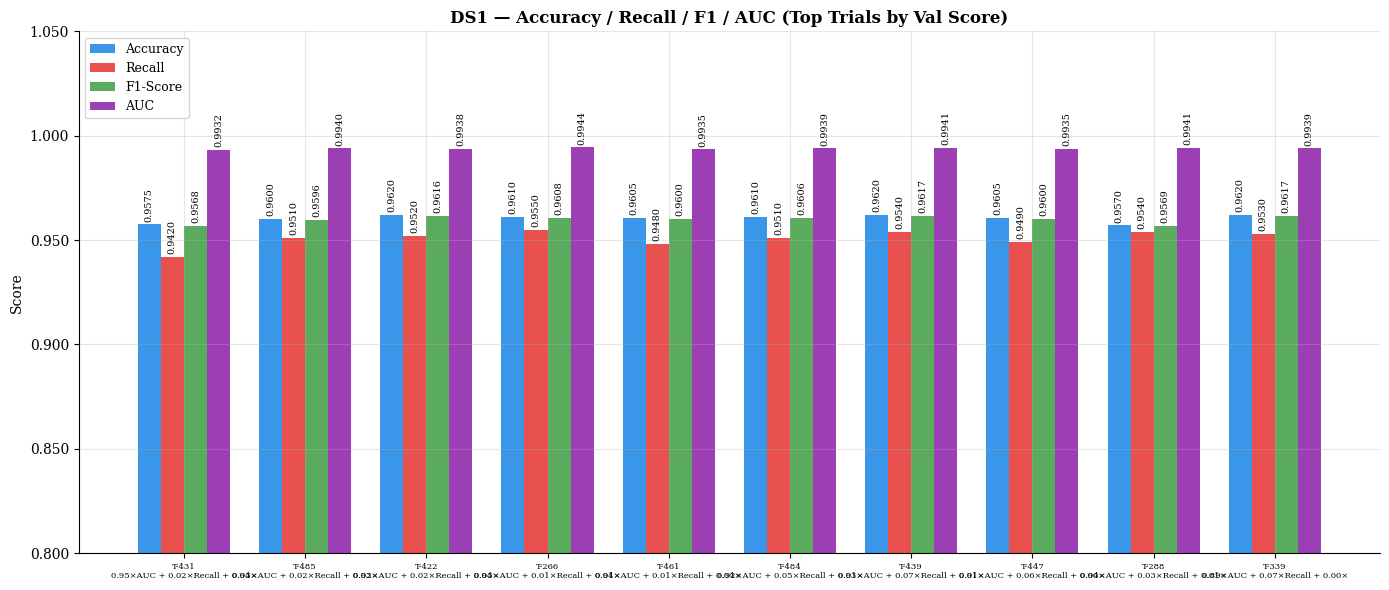

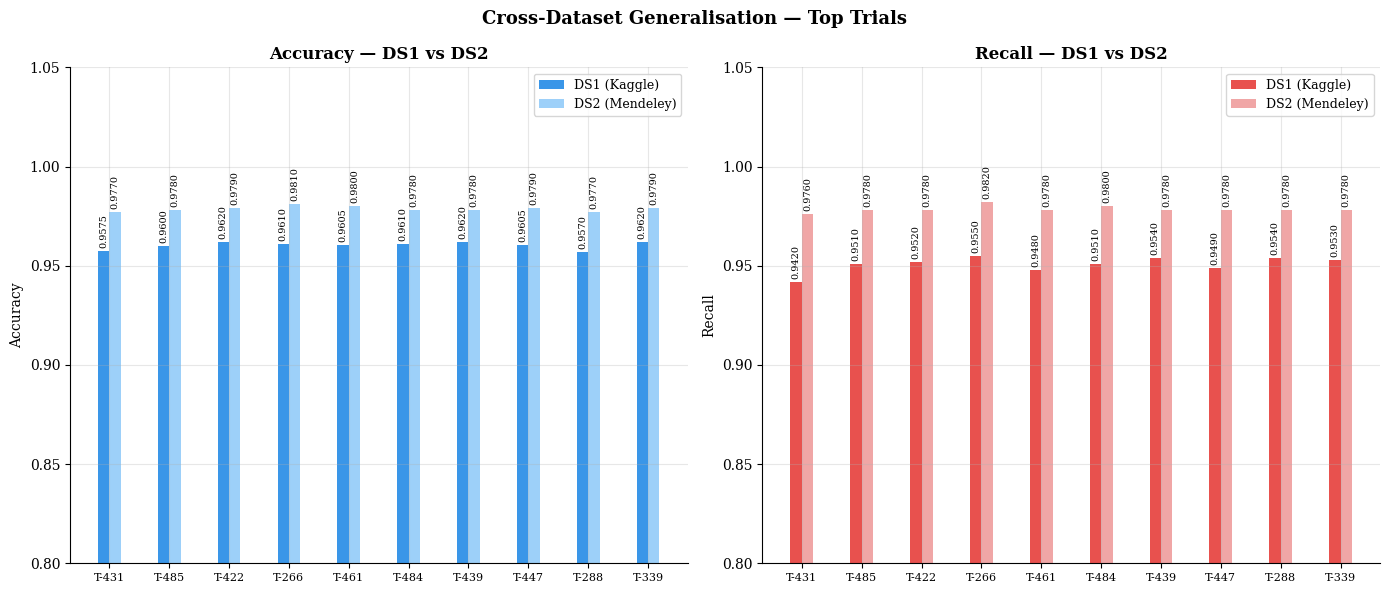

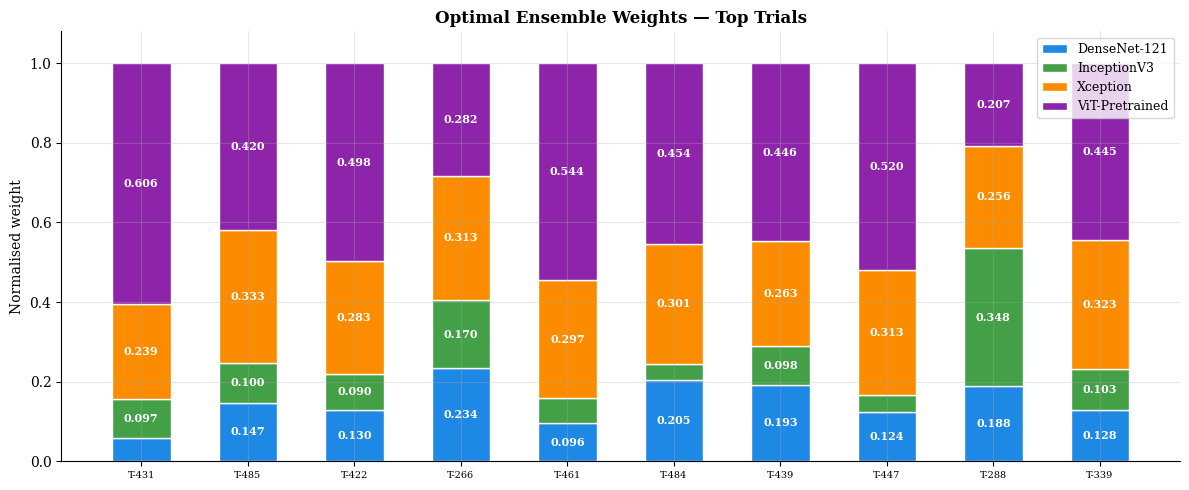

Figures saved.


In [9]:
def _bar_label_bars(ax, containers, fmt='.4f', fontsize=7):
    for bars in containers:
        ax.bar_label(bars, fmt=f'{{:{fmt}}}', fontsize=fontsize, padding=2, rotation=90)

TOP_N = min(10, len(all_trials))
ranked_vis = sorted(all_trials, key=lambda t: t['val_score'], reverse=True)[:TOP_N]
obj_ids = [f"T-{r['trial_id']}" for r in ranked_vis]
x       = np.arange(len(obj_ids))
w       = 0.19

fig, ax = plt.subplots(figsize=(14, 6))
bs = [
    ax.bar(x - 1.5*w, [r['ds1']['accuracy']  for r in ranked_vis], w, label='Accuracy',  color='#1E88E5', alpha=.88),
    ax.bar(x - 0.5*w, [r['ds1']['recall']    for r in ranked_vis], w, label='Recall',    color='#E53935', alpha=.88),
    ax.bar(x + 0.5*w, [r['ds1']['f1']        for r in ranked_vis], w, label='F1-Score',  color='#43A047', alpha=.88),
    ax.bar(x + 1.5*w, [r['ds1']['auc']       for r in ranked_vis], w, label='AUC',       color='#8E24AA', alpha=.88),
]
_bar_label_bars(ax, bs)
ax.set_xticks(x)
ax.set_xticklabels([f'{o}\n{ranked_vis[i]["obj_formula"][:30]}' for i, o in enumerate(obj_ids)], fontsize=6)
ax.set_ylim([0.80, 1.05]); ax.set_ylabel('Score')
ax.set_title('DS1 — Accuracy / Recall / F1 / AUC (Top Trials by Val Score)', fontweight='bold')
ax.legend(fontsize=9); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig1_ds1_metrics.png', dpi=150, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (metric, title, c1, c2) in zip(axes, [
    ('accuracy', 'Accuracy — DS1 vs DS2', '#1E88E5', '#90CAF9'),
    ('recall',   'Recall — DS1 vs DS2',   '#E53935', '#EF9A9A'),
]):
    b1 = ax.bar(x - w/2, [r['ds1'][metric] for r in ranked_vis], w, label='DS1 (Kaggle)',   color=c1, alpha=.88)
    b2 = ax.bar(x + w/2, [r['ds2'][metric] for r in ranked_vis], w, label='DS2 (Mendeley)', color=c2, alpha=.88)
    _bar_label_bars(ax, [b1, b2])
    ax.set_xticks(x); ax.set_xticklabels(obj_ids, fontsize=8)
    ax.set_ylim([0.80, 1.05]); ax.set_ylabel(metric.capitalize())
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
plt.suptitle('Cross-Dataset Generalisation — Top Trials', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig2_ds1_vs_ds2.png', dpi=150, bbox_inches='tight'); plt.show()

MODEL_COLORS = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA']
fig, ax = plt.subplots(figsize=(12, 5))
bottoms = np.zeros(len(obj_ids))
for i, arch in enumerate(MODEL_KEYS):
    wvals = np.array([r['w_model'][arch] for r in ranked_vis])
    bars  = ax.bar(x, wvals, bottom=bottoms, color=MODEL_COLORS[i],
                   label=MODEL_LABELS[arch], edgecolor='white', width=0.55)
    for bar, val in zip(bars, wvals):
        if val > 0.07:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottoms += wvals
ax.set_xticks(x); ax.set_xticklabels(obj_ids, fontsize=7)
ax.set_ylim(0, 1.08); ax.set_ylabel('Normalised weight')
ax.set_title('Optimal Ensemble Weights — Top Trials', fontweight='bold'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig3_weights.png', dpi=150, bbox_inches='tight'); plt.show()

print('Figures saved.')

## 9. Simpan Hasil Objective Search

Menyimpan seluruh trial yang valid ke `all_objectives.json` — berisi val score, formula objektif, bobot model, bobot metrik, serta metrik DS1 dan DS2 per trial. File ini menjadi sumber data untuk analisis lanjutan tanpa perlu menjalankan ulang TPE search.

In [10]:
save_data = {}
for t in all_trials:
    key = f"trial_{t['trial_id']}"
    save_data[key] = {
        'trial_id'   : t['trial_id'],
        'val_score'  : t['val_score'],
        'obj_formula': t['obj_formula'],
        'w_model'    : t['w_model'],
        'w_obj'      : t['w_obj'],
        'ds1'        : {k: v for k, v in t['ds1'].items() if k != 'conf_mat'},
        'ds2'        : {k: v for k, v in t['ds2'].items() if k != 'conf_mat'},
    }

with open(OUTPUT_DIR / 'all_objectives.json', 'w') as fh:
    json.dump(save_data, fh, indent=2)
print(f'Saved: {OUTPUT_DIR / "all_objectives.json"}  ({len(save_data)} trials)')


Saved: D:\Tree-Structured Parzen Estimator\main\[5] ensemble_learning\ensemble_results\all_objectives.json  (500 trials)


---

## 10. Bagian B — Seleksi Trial Terbaik

Memilih trial terbaik berdasarkan *selection score* gabungan DS1 + DS2:

```
selection_score = 0.50 × DS1-AUC  +  0.30 × DS2-AUC
                + 0.10 × DS1-Recall  +  0.10 × DS2-Recall
```

Pendekatan ini memastikan trial yang dipilih bukan hanya optimal di validation (DS1), tapi juga generalise ke distribusi dataset yang berbeda (DS2). Bobot optimal dan formula objektif yang ditemukan disimpan ke `ensemble_weights_best.json`.

In [11]:
def selection_score(trial_res, w=SELECTION_W):
    d1, d2 = trial_res['ds1'], trial_res['ds2']
    return (w['ds1_auc']    * d1['auc']    +
            w['ds2_auc']    * d2['auc']    +
            w['ds1_recall'] * d1['recall'] +
            w['ds2_recall'] * d2['recall'])

ranked = sorted(all_trials, key=selection_score, reverse=True)

print('Top-5 trial berdasarkan selection score:')
print(f'  {"Rank":<5} {"Trial":>6} {"Sel Score":>10} '
      f'{"DS1 AUC":>9} {"DS2 AUC":>9} {"DS1 Rec":>9} {"DS2 Rec":>9}')
print('  ' + '-' * 65)
for rank, tr in enumerate(ranked[:5], 1):
    sc     = selection_score(tr)
    marker = '  ← BEST' if rank == 1 else ''
    print(f'  {rank:<5} {tr["trial_id"]:>6} {sc:>10.6f} '
          f'{tr["ds1"]["auc"]:>9.4f} {tr["ds2"]["auc"]:>9.4f} '
          f'{tr["ds1"]["recall"]:>9.4f} {tr["ds2"]["recall"]:>9.4f}{marker}')

best         = ranked[0]
BEST_WEIGHTS = best['w_model']
best_weights = [BEST_WEIGHTS[k] for k in MODEL_KEYS]
BEST_OBJ_LABEL = best['obj_formula']
BEST_OBJ_ID    = f'Trial-{best["trial_id"]}'
ENS_OBJECTIVE_ID = BEST_OBJ_ID

print(f'\nTrial terpilih  : {BEST_OBJ_ID}')
print(f'Formula objektif: {BEST_OBJ_LABEL}')
print(f'Bobot objektif  : AUC={best["w_obj"]["auc"]:.3f}  '
      f'Recall={best["w_obj"]["recall"]:.3f}  '
      f'F1={best["w_obj"]["f1"]:.3f}  '
      f'Acc={best["w_obj"]["acc"]:.3f}')
print('\nBobot ensemble:')
for k in MODEL_KEYS:
    print(f'  {MODEL_LABELS[k]:<16} {BEST_WEIGHTS[k]:.4f}  ({BEST_WEIGHTS[k]*100:.2f}%)')

with open(OUTPUT_DIR / 'ensemble_weights_best.json', 'w') as f:
    json.dump({
        'trial_id'        : best['trial_id'],
        'objective_label' : BEST_OBJ_LABEL,
        'w_obj'           : best['w_obj'],
        'weights'         : BEST_WEIGHTS,
    }, f, indent=2)
print(f'\nBobot tersimpan → {OUTPUT_DIR / "ensemble_weights_best.json"}')

Top-5 trial berdasarkan selection score:
  Rank   Trial  Sel Score   DS1 AUC   DS2 AUC   DS1 Rec   DS2 Rec
  -----------------------------------------------------------------
  1        460   0.990766    0.9943    0.9964    0.9610    0.9860  ← BEST
  2         86   0.990715    0.9944    0.9966    0.9590    0.9860
  3        365   0.990680    0.9944    0.9965    0.9590    0.9860
  4         13   0.990612    0.9944    0.9967    0.9580    0.9860
  5         71   0.990600    0.9944    0.9966    0.9580    0.9860

Trial terpilih  : Trial-460
Formula objektif: 0.08×AUC + 0.05×Recall + 0.18×F1 + 0.69×Acc
Bobot objektif  : AUC=0.081  Recall=0.054  F1=0.175  Acc=0.690

Bobot ensemble:
  DenseNet-121     0.4706  (47.06%)
  InceptionV3      0.0893  (8.93%)
  Xception         0.2850  (28.50%)
  ViT-Pretrained   0.1551  (15.51%)

Bobot tersimpan → D:\Tree-Structured Parzen Estimator\main\[5] ensemble_learning\ensemble_results\ensemble_weights_best.json


## 11. Scenario II — Evaluasi Ensemble DS1

Menerapkan bobot optimal dari trial terpilih (`BEST_OBJ_ID`) ke DS1 (Kaggle test set):

- Metrik per model dan ensemble dihitung dan dibandingkan dengan baseline paper.
- Tiga visualisasi: pie chart bobot ensemble, ROC curves per model vs ensemble, dan confusion matrix.
- Bar chart perbandingan dengan Sarıateş & Özbay dan Mahmud et al. Label `N/R` pada bar AUC Sarıateş & Özbay ditempatkan secara dinamis berdasarkan posisi kolom AUC — aman jika urutan metrik berubah.
- Hasil disimpan ke `scenario2_results.json`.

  Scenario II — DS1 Results  (Objective: Trial-460)
  Model              Accuracy  Precision   Recall       F1      AUC  Δ Acc vs Paper
  ------------------------------------------------------------------------------
  DenseNet-121         0.9590     0.9646   0.9530   0.9588   0.9883  +0.0140
  InceptionV3          0.9445     0.9441   0.9450   0.9445   0.9855  +0.0325
  Xception             0.9495     0.9499   0.9490   0.9495   0.9865  +0.0115
  ViT-Pretrained       0.9510     0.9698   0.9310   0.9500   0.9898  +0.0685
  ------------------------------------------------------------------------------
  Ensemble (ours)      0.9660     0.9707   0.9610   0.9658   0.9943  +0.0135
  Sarıateş & Özbay [ref]     0.9525     0.9420   0.9622   0.9520      N/R


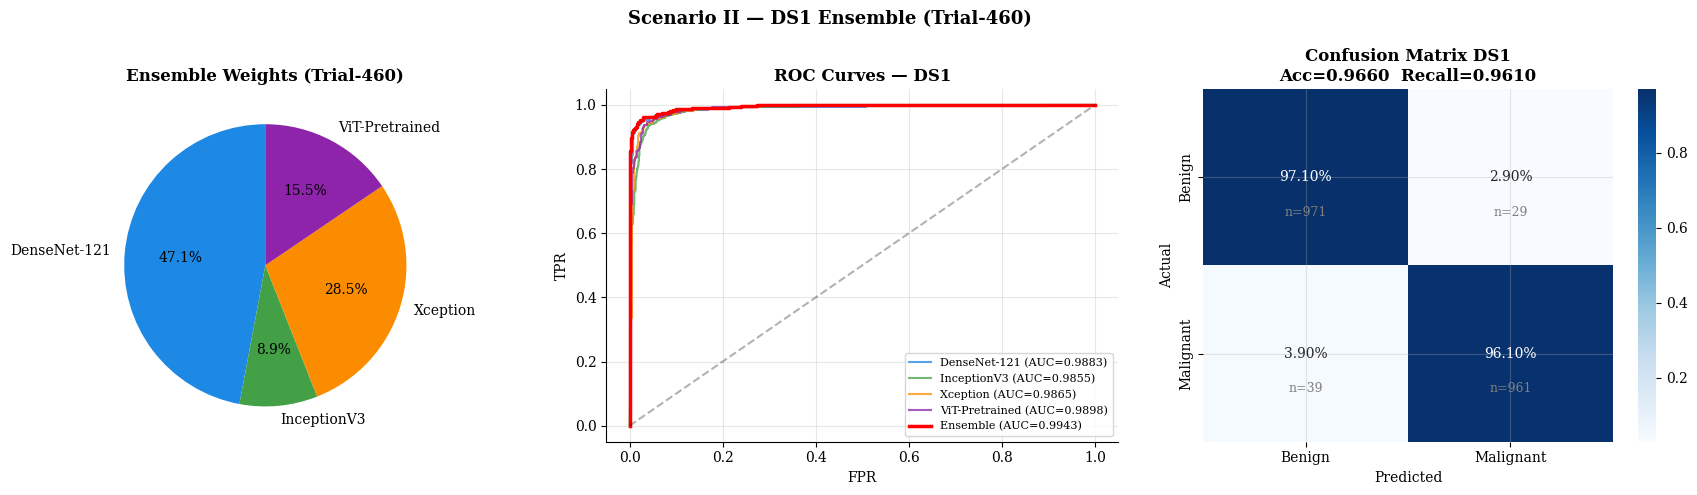

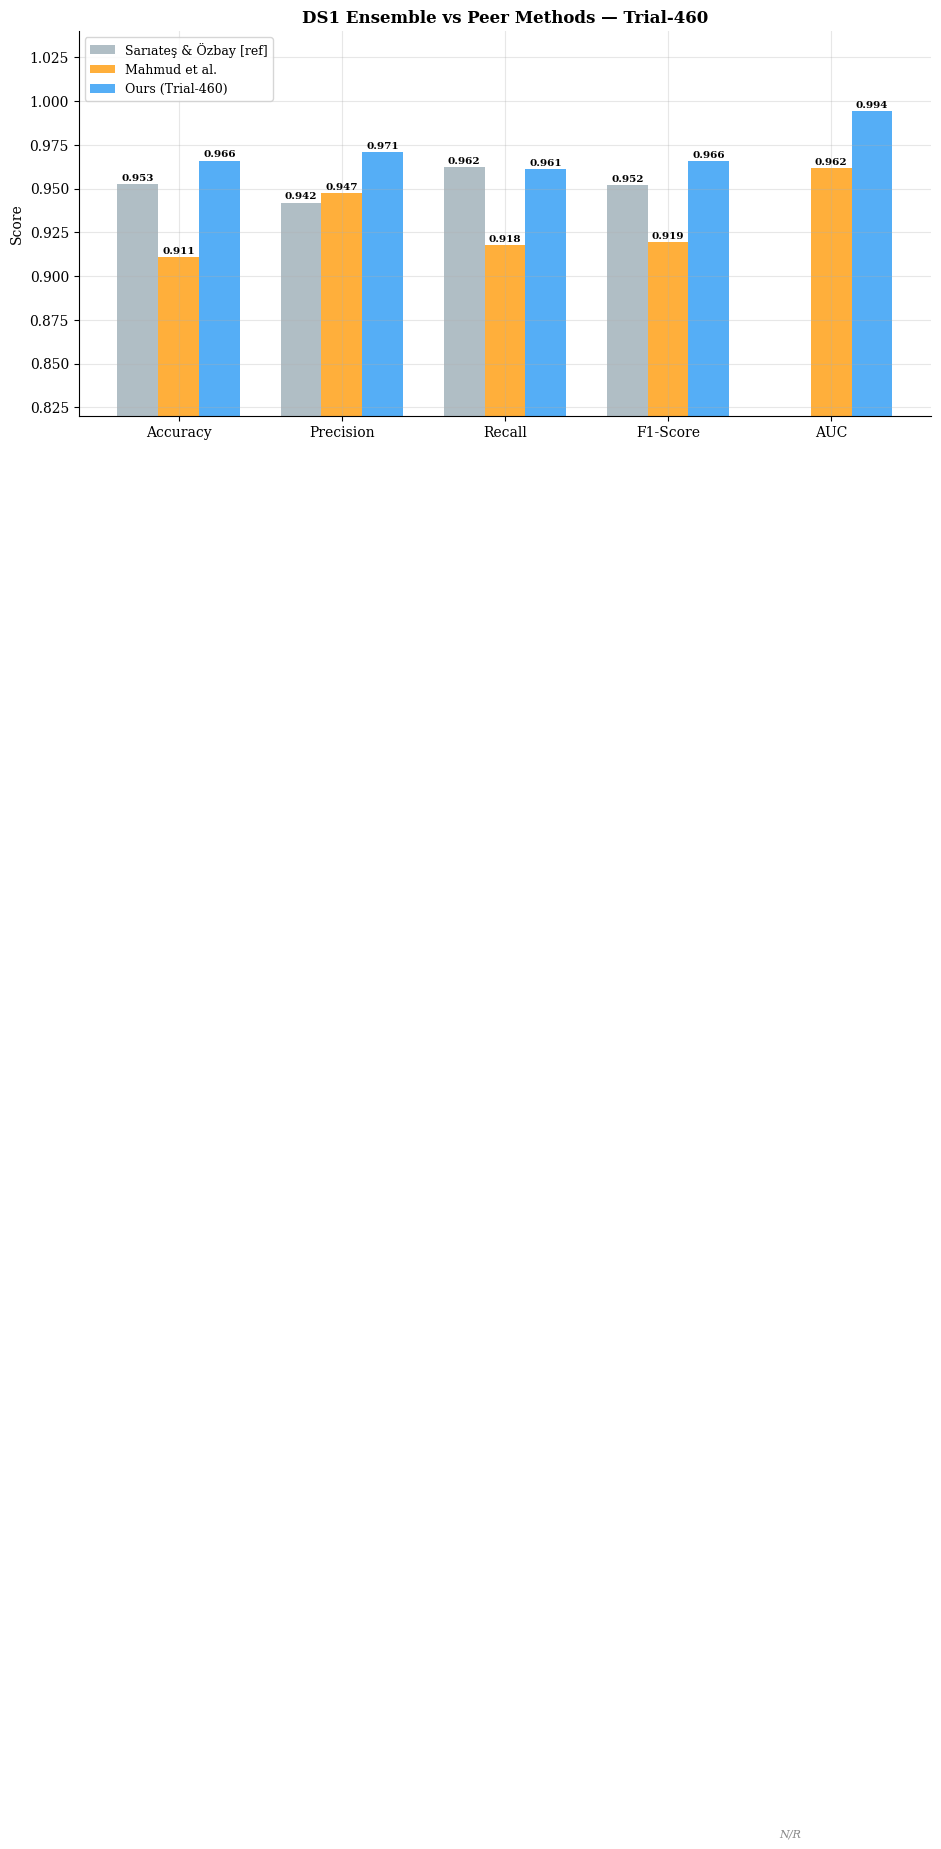

Scenario II outputs saved.


In [12]:
all_metrics_ds1 = {
    arch: compute_metrics(ds1_labels, all_probs_ds1[arch])
    for arch in MODEL_KEYS if arch in all_probs_ds1
}
ens_probs   = weighted_ensemble(all_probs_ds1, best_weights, MODEL_KEYS)
ens_metrics = compute_metrics(ds1_labels, ens_probs)
weights_dict = {k: float(w) for k, w in zip(MODEL_KEYS, best_weights)}

pens = PAPER_REF['Ensemble']

print('=' * 80)
print(f'  Scenario II — DS1 Results  (Objective: {ENS_OBJECTIVE_ID})')
print('=' * 80)
print(f'  {"Model":<16} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AUC":>8}  Δ Acc vs Paper')
print('  ' + '-' * 78)
for arch in MODEL_KEYS:
    m = all_metrics_ds1[arch]; p = PAPER_REF[MODEL_LABELS[arch]]
    print(f'  {MODEL_LABELS[arch]:<16} {m["accuracy"]:>10.4f} {m["precision"]:>10.4f} '
          f'{m["recall"]:>8.4f} {m["f1"]:>8.4f} {m["auc"]:>8.4f}  '
          f'{m["accuracy"]-p["accuracy"]:>+.4f}')
print('  ' + '-' * 78)
print(f'  {"Ensemble (ours)":<16} {ens_metrics["accuracy"]:>10.4f} {ens_metrics["precision"]:>10.4f} '
      f'{ens_metrics["recall"]:>8.4f} {ens_metrics["f1"]:>8.4f} {ens_metrics["auc"]:>8.4f}  '
      f'{ens_metrics["accuracy"]-pens["accuracy"]:>+.4f}')
print(f'  {"Sarıateş & Özbay [ref]":<16} {pens["accuracy"]:>10.4f} {pens["precision"]:>10.4f} '
      f'{pens["recall"]:>8.4f} {pens["f1"]:>8.4f}      N/R')
print('=' * 80)

COLORS = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA', '#E53935']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].pie(best_weights, labels=[MODEL_LABELS[k] for k in MODEL_KEYS],
            autopct='%1.1f%%', colors=COLORS[:4], startangle=90, textprops={'fontsize': 10})
axes[0].set_title(f'Ensemble Weights ({ENS_OBJECTIVE_ID})', fontweight='bold')

for arch, color in zip(MODEL_KEYS, COLORS):
    fpr, tpr, _ = roc_curve(ds1_labels, all_probs_ds1[arch])
    axes[1].plot(fpr, tpr, color=color, lw=1.5, alpha=.75,
                 label=f'{MODEL_LABELS[arch]} (AUC={all_metrics_ds1[arch]["auc"]:.4f})')
fpr_e, tpr_e, _ = roc_curve(ds1_labels, ens_probs)
axes[1].plot(fpr_e, tpr_e, 'r-', lw=2.5, label=f'Ensemble (AUC={ens_metrics["auc"]:.4f})')
axes[1].plot([0,1],[0,1],'k--',alpha=.3); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves — DS1', fontweight='bold'); axes[1].legend(fontsize=8, loc='lower right')

cm = np.array(ens_metrics['conf_mat'])
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
for i in range(2):
    for j in range(2):
        axes[2].text(j+.5, i+.72, f'n={cm[i,j]}', ha='center', fontsize=9, color='gray')
axes[2].set_title(f'Confusion Matrix DS1\nAcc={ens_metrics["accuracy"]:.4f}  Recall={ens_metrics["recall"]:.4f}',
                  fontweight='bold'); axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.suptitle(f'Scenario II — DS1 Ensemble ({ENS_OBJECTIVE_ID})', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_overview.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

metrics_c = ['accuracy', 'precision', 'recall', 'f1', 'auc']
m_lbs     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(m_lbs)); w = 0.25; fig, ax = plt.subplots(figsize=(11, 5))
m16 = SOTA_REF['Mahmud_DS1']
b1 = ax.bar(x-w,   [pens.get(m, float('nan')) for m in metrics_c], w, label='Sarıateş & Özbay [ref]', color='#B0BEC5')
b2 = ax.bar(x,     [m16[m] for m in metrics_c],                     w, label='Mahmud et al.',          color='#FFA726', alpha=.9)
b3 = ax.bar(x+w,   [ens_metrics[m] for m in metrics_c],             w, label=f'Ours ({ENS_OBJECTIVE_ID})', color='#42A5F5', alpha=.9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+.002, f'{h:.3f}', ha='center', fontsize=7.5, fontweight='bold')

_auc_idx   = metrics_c.index('auc')
_ylim_bot  = ax.get_ylim()[0]
_nr_ypos   = _ylim_bot + 0.008
_nr_xpos   = float(x[_auc_idx] - w)
ax.text(_nr_xpos, _nr_ypos, 'N/R', ha='center', fontsize=8, color='#888', style='italic')

ax.set_xticks(x); ax.set_xticklabels(m_lbs); ax.set_ylim([0.82, 1.04])
ax.set_ylabel('Score'); ax.set_title(f'DS1 Ensemble vs Peer Methods — {ENS_OBJECTIVE_ID}', fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_peer_ds1.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

with open(OUTPUT_DIR / 'scenario2_results.json', 'w') as f:
    json.dump({
        'ensemble'  : {k: v for k, v in ens_metrics.items() if k != 'conf_mat'},
        'individual': {k: {m: v for m, v in all_metrics_ds1[k].items() if m != 'conf_mat'} for k in MODEL_KEYS},
        'weights'   : weights_dict,
    }, f, indent=2)
print('Scenario II outputs saved.')

## 12. Scenario III — Evaluasi Cross-Dataset (DS2)

Menerapkan ensemble yang sama (bobot identik dari Scenario II) ke DS2 (Mendeley/Hasnainjaved) tanpa fine-tuning — mengukur generalisasi lintas distribusi dataset:

- Tabel delta: perbandingan DS1 vs DS2 per model dan ensemble untuk melihat degradasi performa.
- Confusion matrix berdampingan DS1 vs DS2.
- Bar chart perbandingan dengan Mahmud et al. dan Sabir & Mehmood pada DS2.
- Hasil disimpan ke `scenario3_results.json`.

  Scenario III — Cross-Dataset Generalisation (DS1 → DS2)
  Model              DS1 Acc   DS2 Acc    Δ Acc   DS1 Rec   DS2 Rec  Paper Acc Δ vs Paper
  ----------------------------------------------------------------------------------
  DenseNet-121        0.9590    0.9820  +0.0230    0.9530    0.9860     0.9450    +0.0140
  InceptionV3         0.9445    0.9580  +0.0135    0.9450    0.9580     0.9120    +0.0325
  Xception            0.9495    0.9680  +0.0185    0.9490    0.9700     0.9380    +0.0115
  ViT-Pretrained      0.9510    0.9690  +0.0180    0.9310    0.9620     0.8825    +0.0685
  ----------------------------------------------------------------------------------
  Ensemble            0.9660    0.9820  +0.0160    0.9610    0.9860     0.9525    +0.0135


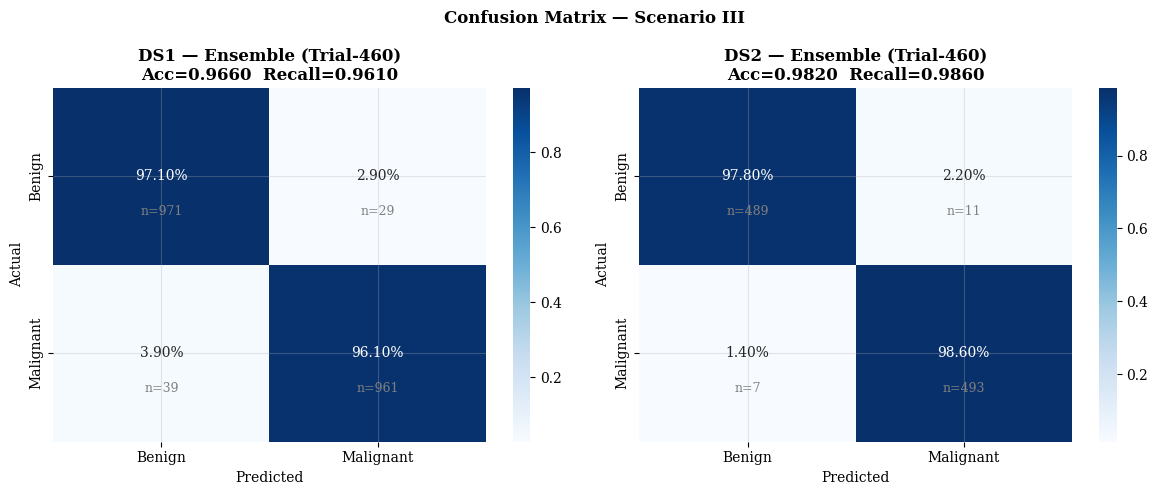

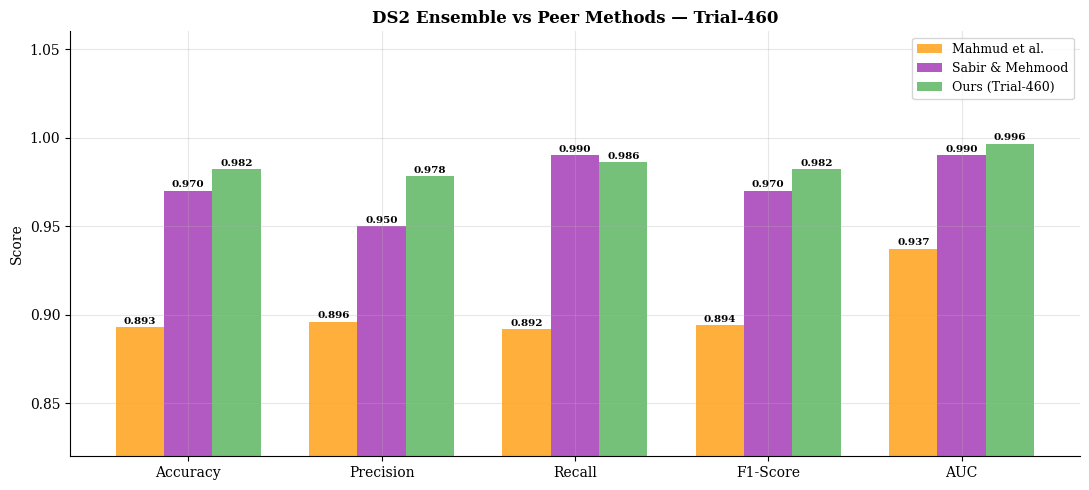

Scenario III outputs saved.


In [13]:
if not all_probs_ds2:
    raise RuntimeError(
        'all_probs_ds2 kosong: tidak ada model DS2 yang berhasil dimuat.\n'
        'Jalankan Cell 3 (Load Prediction Arrays) dengan file yang lengkap.'
    )

s3_metrics = {
    arch: compute_metrics(ds2_labels, all_probs_ds2[arch])
    for arch in MODEL_KEYS if arch in all_probs_ds2
}
ens_probs_ds2   = weighted_ensemble(all_probs_ds2, best_weights, MODEL_KEYS)
ens_metrics_ds2 = compute_metrics(ds2_labels, ens_probs_ds2)

pens = PAPER_REF['Ensemble']

print('=' * 84)
print('  Scenario III — Cross-Dataset Generalisation (DS1 → DS2)')
print('=' * 84)
print(f'  {"Model":<16} {"DS1 Acc":>9} {"DS2 Acc":>9} {"Δ Acc":>8} '
      f'{"DS1 Rec":>9} {"DS2 Rec":>9} {"Paper Acc":>10} {"Δ vs Paper":>10}')
print('  ' + '-' * 82)
for arch in MODEL_KEYS:
    if arch not in s3_metrics: continue
    m1 = all_metrics_ds1[arch]; m2 = s3_metrics[arch]; p = PAPER_REF[MODEL_LABELS[arch]]
    print(f'  {MODEL_LABELS[arch]:<16} {m1["accuracy"]:>9.4f} {m2["accuracy"]:>9.4f} '
          f'{m2["accuracy"]-m1["accuracy"]:>+8.4f} {m1["recall"]:>9.4f} {m2["recall"]:>9.4f} '
          f'{p["accuracy"]:>10.4f} {m1["accuracy"]-p["accuracy"]:>+10.4f}')
print('  ' + '-' * 82)
print(f'  {"Ensemble":<16} {ens_metrics["accuracy"]:>9.4f} {ens_metrics_ds2["accuracy"]:>9.4f} '
      f'{ens_metrics_ds2["accuracy"]-ens_metrics["accuracy"]:>+8.4f} '
      f'{ens_metrics["recall"]:>9.4f} {ens_metrics_ds2["recall"]:>9.4f} '
      f'{pens["accuracy"]:>10.4f} {ens_metrics["accuracy"]-pens["accuracy"]:>+10.4f}')
print('=' * 84)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, ds_m) in zip(axes, [
    (f'DS1 — Ensemble ({ENS_OBJECTIVE_ID})', ens_metrics),
    (f'DS2 — Ensemble ({ENS_OBJECTIVE_ID})', ens_metrics_ds2),
]):
    cm = np.array(ds_m['conf_mat'])
    sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j+.5, i+.72, f'n={cm[i,j]}', ha='center', fontsize=9, color='gray')
    ax.set_title(f'{title}\nAcc={ds_m["accuracy"]:.4f}  Recall={ds_m["recall"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix — Scenario III', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'scenario3_confmat.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

metrics_c = ['accuracy', 'precision', 'recall', 'f1', 'auc']
m_lbs     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(m_lbs)); w = 0.25; fig, ax = plt.subplots(figsize=(11, 5))
m16_ds2 = SOTA_REF['Mahmud_DS2']; m17 = SOTA_REF['Sabir_DS2']
b1 = ax.bar(x-w, [m16_ds2[m] for m in metrics_c],    w, label='Mahmud et al.',          color='#FFA726', alpha=.9)
b2 = ax.bar(x,   [m17[m] for m in metrics_c],          w, label='Sabir & Mehmood',        color='#AB47BC', alpha=.9)
b3 = ax.bar(x+w, [ens_metrics_ds2[m] for m in metrics_c], w, label=f'Ours ({ENS_OBJECTIVE_ID})', color='#66BB6A', alpha=.9)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(m_lbs); ax.set_ylim([0.82, 1.06])
ax.set_ylabel('Score'); ax.set_title(f'DS2 Ensemble vs Peer Methods — {ENS_OBJECTIVE_ID}', fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario3_peer_ds2.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

with open(OUTPUT_DIR / 'scenario3_results.json', 'w') as f:
    json.dump({
        'ds1_ensemble'   : {k: v for k, v in ens_metrics.items() if k != 'conf_mat'},
        'ds2_ensemble'   : {k: v for k, v in ens_metrics_ds2.items() if k != 'conf_mat'},
        'individual_ds1' : {k: {m: v for m, v in all_metrics_ds1[k].items() if m != 'conf_mat'} for k in MODEL_KEYS},
        'individual_ds2' : {k: {m: v for m, v in s3_metrics[k].items() if m != 'conf_mat'} for k in MODEL_KEYS},
    }, f, indent=2)
print('Scenario III outputs saved.')

## 13. Consolidated Summary

Menghasilkan tabel ringkasan akhir yang menggabungkan metrik DS1 dan DS2 untuk semua model dan ensemble. Kolom DS2 menampilkan `'-'` (bukan `0.0000`) jika data model tidak tersedia, agar tidak menyesatkan. Tabel disimpan ke `final_summary.csv`.

In [14]:

if not s3_metrics:
    print('WARNING: s3_metrics kosong — kolom DS2 di tabel summary akan berisi 0.0 (data tidak tersedia).')

rows = []
for arch in MODEL_KEYS:
    label = MODEL_LABELS[arch]
    m1 = all_metrics_ds1.get(arch, {}); m3 = s3_metrics.get(arch, {}); p = PAPER_REF[label]
    bp = tpe_best_params.get(arch, {})
    _ds2_acc    = f"{m3['accuracy']:.4f}"  if m3 else '-'
    _ds2_prec   = f"{m3['precision']:.4f}" if m3 else '-'
    _ds2_recall = f"{m3['recall']:.4f}"    if m3 else '-'
    _ds2_f1     = f"{m3['f1']:.4f}"        if m3 else '-'
    _ds2_auc    = f"{m3['auc']:.4f}"       if m3 else '-'
    rows.append({
        'Model'      : label,
        'Paper Acc'  : f"{p['accuracy']:.4f}",
        'DS1 Acc'    : f"{m1.get('accuracy',0):.4f}",
        'DS1 Prec'   : f"{m1.get('precision',0):.4f}",
        'DS1 Recall' : f"{m1.get('recall',0):.4f}",
        'DS1 F1'     : f"{m1.get('f1',0):.4f}",
        'DS1 AUC'    : f"{m1.get('auc',0):.4f}",
        'DS2 Acc'    : _ds2_acc,
        'DS2 Prec'   : _ds2_prec,
        'DS2 Recall' : _ds2_recall,
        'DS2 F1'     : _ds2_f1,
        'DS2 AUC'    : _ds2_auc,
        'Δ Acc'      : f"{m1.get('accuracy',0)-p['accuracy']:+.4f}",
        'Best LR'    : f"{bp.get('lr',0):.2e}" if bp else '-',
        'Optimiser'  : bp.get('optimizer_name', '-'),
    })
rows.append({
    'Model'     : 'Ensemble',
    'Paper Acc' : f"{pens['accuracy']:.4f}",
    'DS1 Acc'   : f"{ens_metrics['accuracy']:.4f}",
    'DS1 Prec'  : f"{ens_metrics['precision']:.4f}",
    'DS1 Recall': f"{ens_metrics['recall']:.4f}",
    'DS1 F1'    : f"{ens_metrics['f1']:.4f}",
    'DS1 AUC'   : f"{ens_metrics['auc']:.4f}",
    'DS2 Acc'   : f"{ens_metrics_ds2['accuracy']:.4f}",
    'DS2 Prec'  : f"{ens_metrics_ds2['precision']:.4f}",
    'DS2 Recall': f"{ens_metrics_ds2['recall']:.4f}",
    'DS2 F1'    : f"{ens_metrics_ds2['f1']:.4f}",
    'DS2 AUC'   : f"{ens_metrics_ds2['auc']:.4f}",
    'Δ Acc'     : f"{ens_metrics['accuracy']-pens['accuracy']:+.4f}",
    'Best LR'   : '-', 'Optimiser': '-',
})

df_sum = pd.DataFrame(rows)
display(df_sum)
df_sum.to_csv(OUTPUT_DIR / 'final_summary.csv', index=False)

print()
print(f'Ensemble DS1  : acc={ens_metrics["accuracy"]:.4f}  prec={ens_metrics["precision"]:.4f}  recall={ens_metrics["recall"]:.4f}  f1={ens_metrics["f1"]:.4f}  AUC={ens_metrics["auc"]:.4f}')
print(f'Ensemble DS2  : acc={ens_metrics_ds2["accuracy"]:.4f}  prec={ens_metrics_ds2["precision"]:.4f}  recall={ens_metrics_ds2["recall"]:.4f}  f1={ens_metrics_ds2["f1"]:.4f}  AUC={ens_metrics_ds2["auc"]:.4f}')
print(f'Paper target  : acc={pens["accuracy"]:.4f}  recall={pens["recall"]:.4f}')
delta = ens_metrics['accuracy'] - pens['accuracy']
print(f'Δ vs paper    : {delta:+.4f}  ({"Exceeds target" if delta >= 0 else "Below target"})')
print(f'\nAll outputs → {OUTPUT_DIR}')
print()
for fp in sorted(OUTPUT_DIR.glob('*')):
    if fp.is_file():
        print(f'  {fp.name:<48} ({fp.stat().st_size/1024:.1f} KB)')

,Model,Paper Acc,DS1 Acc,DS1 Prec,DS1 Recall,DS1 F1,DS1 AUC,DS2 Acc,DS2 Prec,DS2 Recall,DS2 F1,DS2 AUC,Δ Acc,Best LR,Optimiser
0,DenseNet-121,0.9450,0.9590,0.9646,0.9530,0.9588,0.9883,0.9820,0.9782,0.9860,0.9821,0.9906,+0.0140,4.00e-03,adamw
1,InceptionV3,0.9120,0.9445,0.9441,0.9450,0.9445,0.9855,0.9580,0.9580,0.9580,0.9580,0.9886,+0.0325,1.91e-03,adam
2,Xception,0.9380,0.9495,0.9499,0.9490,0.9495,0.9865,0.9680,0.9661,0.9700,0.9681,0.9880,+0.0115,3.16e-03,adam
3,ViT-Pretrained,0.8825,0.9510,0.9698,0.9310,0.9500,0.9898,0.9690,0.9757,0.9620,0.9688,0.9961,+0.0685,-,-
4,Ensemble,0.9525,0.9660,0.9707,0.9610,0.9658,0.9943,0.9820,0.9782,0.9860,0.9821,0.9964,+0.0135,-,-



Ensemble DS1  : acc=0.9660  prec=0.9707  recall=0.9610  f1=0.9658  AUC=0.9943
Ensemble DS2  : acc=0.9820  prec=0.9782  recall=0.9860  f1=0.9821  AUC=0.9964
Paper target  : acc=0.9525  recall=0.9622
Δ vs paper    : +0.0135  (Exceeds target)

All outputs → D:\Tree-Structured Parzen Estimator\main\[5] ensemble_learning\ensemble_results

  all_objectives.json                              (447.1 KB)
  ensemble_weights_best.json                       (0.4 KB)
  fig1_ds1_metrics.png                             (70.4 KB)
  fig2_ds1_vs_ds2.png                              (71.7 KB)
  fig3_weights.png                                 (79.2 KB)
  final_summary.csv                                (0.7 KB)
  objective_comparison.csv                         (1.3 KB)
  scenario2_overview.png                           (137.4 KB)
  scenario2_peer_ds1.png                           (70.2 KB)
  scenario2_results.json                           (1.2 KB)
  scenario3_confmat.png                            (67.

In [16]:
# DIAGNOSTIK: pastikan DS1 dan DS2 berbeda per model
print("=== Cek cross-contamination DS1 vs DS2 ===")
for arch in MODEL_KEYS:
    p1 = all_probs_ds1.get(arch)
    p2 = all_probs_ds2.get(arch)
    if p1 is None or p2 is None:
        print(f"  {arch}: MISSING")
        continue
    
    print(f"  {arch}: shape DS1={p1.shape} DS2={p2.shape}")
    print(f"    DS1 → min={p1.min():.4f}  max={p1.max():.4f}  mean={p1.mean():.4f}  std={p1.std():.4f}")
    print(f"    DS2 → min={p2.min():.4f}  max={p2.max():.4f}  mean={p2.mean():.4f}  std={p2.std():.4f}")
    
    # Cek apakah DS2 adalah subset/copy dari DS1 (ambil slice terpendek)
    n = min(len(p1), len(p2))
    slice_identical = np.allclose(p1[:n], p2[:n])
    print(f"    Slice [{n}] identical: {slice_identical}")
    print()

# Cek juga apakah semua model DS2 identik satu sama lain
print("=== Cek apakah model DS2 saling identik ===")
archs_available = [a for a in MODEL_KEYS if a in all_probs_ds2]
for i in range(len(archs_available)):
    for j in range(i+1, len(archs_available)):
        a, b = archs_available[i], archs_available[j]
        pa, pb = all_probs_ds2[a], all_probs_ds2[b]
        if pa.shape == pb.shape:
            identical = np.allclose(pa, pb)
            print(f"  DS2 {a} vs {b}: identical={identical}")
        else:
            print(f"  DS2 {a} vs {b}: shape mismatch {pa.shape} vs {pb.shape}")

=== Cek cross-contamination DS1 vs DS2 ===
  densenet121: shape DS1=(2000,) DS2=(1000,)
    DS1 → min=0.0052  max=0.9984  mean=0.4967  std=0.4667
    DS2 → min=0.0059  max=0.9986  mean=0.5104  std=0.4747
    Slice [1000] identical: False

  inception_v3: shape DS1=(2000,) DS2=(1000,)
    DS1 → min=0.0000  max=1.0000  mean=0.4950  std=0.4706
    DS2 → min=0.0000  max=1.0000  mean=0.4960  std=0.4806
    Slice [1000] identical: False

  xception: shape DS1=(2000,) DS2=(1000,)
    DS1 → min=0.0197  max=0.9850  mean=0.5025  std=0.4112
    DS2 → min=0.0357  max=0.9868  mean=0.5068  std=0.4188
    Slice [1000] identical: False

  vit_scratch: shape DS1=(2000,) DS2=(1000,)
    DS1 → min=0.0191  max=0.9959  mean=0.4812  std=0.4374
    DS2 → min=0.0194  max=0.9962  mean=0.5050  std=0.4584
    Slice [1000] identical: False

=== Cek apakah model DS2 saling identik ===
  DS2 densenet121 vs inception_v3: identical=False
  DS2 densenet121 vs xception: identical=False
  DS2 densenet121 vs vit_scratch:

In [17]:
# DIAGNOSTIK LANJUT: hitung ulang manual dan bandingkan
print("=== Metrik individual DS2 ===")
for arch in MODEL_KEYS:
    m = compute_metrics(ds2_labels, all_probs_ds2[arch])
    print(f"  {MODEL_LABELS[arch]:<16}  acc={m['accuracy']:.6f}  rec={m['recall']:.6f}  "
          f"f1={m['f1']:.6f}  auc={m['auc']:.6f}")

print()
print("=== Bobot ensemble yang dipakai ===")
for k, w in zip(MODEL_KEYS, best_weights):
    print(f"  {MODEL_LABELS[k]:<16}  {w:.6f}  ({w*100:.2f}%)")

print()
print("=== Ensemble DS2 dihitung ulang dari scratch ===")
ens_manual = np.zeros(1000, dtype=np.float64)
for k, w in zip(MODEL_KEYS, best_weights):
    ens_manual += w * all_probs_ds2[k]

m_manual = compute_metrics(ds2_labels, ens_manual)
print(f"  Manual ensemble:  acc={m_manual['accuracy']:.6f}  rec={m_manual['recall']:.6f}  "
      f"f1={m_manual['f1']:.6f}  auc={m_manual['auc']:.6f}")

print()
print("=== Bandingkan prob ensemble vs DenseNet DS2 ===")
ens_ds2_probs = weighted_ensemble(all_probs_ds2, best_weights, MODEL_KEYS)
diff = ens_ds2_probs - all_probs_ds2['densenet121']
print(f"  Max diff  : {np.abs(diff).max():.8f}")
print(f"  Mean diff : {np.abs(diff).mean():.8f}")

print()
print("=== Nilai ens_metrics_ds2 yang tersimpan di memori ===")
print(f"  acc={ens_metrics_ds2['accuracy']:.6f}  rec={ens_metrics_ds2['recall']:.6f}  "
      f"f1={ens_metrics_ds2['f1']:.6f}  auc={ens_metrics_ds2['auc']:.6f}")

print()
print("=== ds2_labels distribusi ===")
print(f"  Total: {len(ds2_labels)}  Benign: {(ds2_labels==0).sum()}  Malignant: {(ds2_labels==1).sum()}")

=== Metrik individual DS2 ===
  DenseNet-121      acc=0.982000  rec=0.986000  f1=0.982072  auc=0.990600
  InceptionV3       acc=0.958000  rec=0.958000  f1=0.958000  auc=0.988628
  Xception          acc=0.968000  rec=0.970000  f1=0.968064  auc=0.987988
  ViT-Pretrained    acc=0.969000  rec=0.962000  f1=0.968781  auc=0.996072

=== Bobot ensemble yang dipakai ===
  DenseNet-121      0.470575  (47.06%)
  InceptionV3       0.089338  (8.93%)
  Xception          0.284971  (28.50%)
  ViT-Pretrained    0.155115  (15.51%)

=== Ensemble DS2 dihitung ulang dari scratch ===
  Manual ensemble:  acc=0.982000  rec=0.986000  f1=0.982072  auc=0.996380

=== Bandingkan prob ensemble vs DenseNet DS2 ===
  Max diff  : 0.37026877
  Mean diff : 0.02854222

=== Nilai ens_metrics_ds2 yang tersimpan di memori ===
  acc=0.982000  rec=0.986000  f1=0.982072  auc=0.996380

=== ds2_labels distribusi ===
  Total: 1000  Benign: 500  Malignant: 500
